In [329]:
import pandas as pd
import numpy as np

# library that displays outputs in a table format
from IPython.display import display

# Load dataset
df = pd.read_csv('../data/interim/covid19_tweets.csv')

In [288]:
def detect_variable_types(df, target_col=None):
    """Automatically detect variable types in a DataFrame."""
    types = {}
    
    for col in df.columns:
        if col == target_col:
            types[col] = 'target'
        elif pd.api.types.is_datetime64_any_dtype(df[col]):
            types[col] = 'datetime'
        elif pd.api.types.is_numeric_dtype(df[col]):
            if df[col].nunique() == 2:
                types[col] = 'binary'
            else:
                types[col] = 'numerical'
        elif df[col].nunique() < 20:
            # Threshold for categorical
            types[col] = 'categorical'
        elif df[col].dtype == 'object':
            # Check if it's text (long strings) or categorical
            avg_length = df[col].astype(str).str.len().mean()
            if avg_length > 50:
                types[col] = 'text'
            else:
                types[col] = 'categorical'
        else:
            types[col] = 'other'
    
    return types

In [289]:
var_types = detect_variable_types(df, target_col=None)
var_types

{'user_name': 'categorical',
 'user_location': 'categorical',
 'user_description': 'text',
 'user_created': 'categorical',
 'user_followers': 'numerical',
 'user_friends': 'numerical',
 'user_favourites': 'numerical',
 'user_verified': 'binary',
 'date': 'categorical',
 'text': 'text',
 'hashtags': 'categorical',
 'source': 'categorical',
 'is_retweet': 'numerical'}

# Data Preparation

In [290]:
# Before proceeding, we need to handle user_name because it is a sensitive feature.

# Mapping from user_name to an integer ID
unique_users = df['user_name'].astype(str).unique()
user_id_map = {name: i for i, name in enumerate(unique_users)}

df['user_id'] = df['user_name'].astype(str).map(user_id_map)

df[['user_name', 'user_id']].head(10)

,user_name,user_id
0,ᏉᎥ☻լꂅϮ,0
1,Tom Basile 🇺🇸,1
2,Time4fisticuffs,2
3,ethel mertz,3
4,DIPR-J&K,4
5,🎹 Franz Schubert,5
6,hr bartender,6
7,Derbyshire LPC,7
8,Prathamesh Bendre,8
9,Member of Christ 🇨🇳🇺🇸🇮🇳🇮🇩🇧🇷🇳🇬🇧🇩🇷🇺,9


### Observations:
To align with AI‑ethics and data‑minimisation principles, this project takes extra steps to protect user privacy and avoid unnecessary processing of potentially sensitive information.

First, the `user_name` column is not used directly in modelling. Where user‑level information is needed (for example, to count tweets per account), usernames are mapped to integer IDs (`user_id`) and the original user_name values are then dropped from the working dataset. This pseudonymisation preserves the ability to reason about user‑level patterns without retaining direct identifiers.

Second, the `user_description` column, which contains free‑text profile bios, is removed entirely and not used as a feature. These descriptions often reveal roles (e.g., “columnist”, “professor”), affiliations (“official account of…”, “news alerts from…”), and sometimes religious, political, or other sensitive attributes. While such information could potentially correlate with tweet tone, it is not strictly necessary for the core task of classifying each tweet as fear‑mongering, calm‑negative/concerned, or neutral/factual. To treat user data with appropriate sensitivity and protection, the project restricts itself to tweet text and non‑identifying metadata (such as timestamps and simple engagement counts), documenting this choice as an explicit application of data‑minimisation and privacy‑by‑design principles.

Thirdly, the `source` column will be dropped because:
- It primarily encodes user device's information.
- It has no clear, theory‑backed link to tweet tone or factuality.

In [291]:
# Dropping user_name column because we no longer need it.
df = df.drop(columns=['user_name'])

In [292]:
df['user_description'].head(24)

0     wednesday addams as a disney princess keepin i...
1     Husband, Father, Columnist & Commentator. Auth...
2     #Christian #Catholic #Conservative #Reagan #Re...
3     #Browns #Indians #ClevelandProud #[]_[] #Cavs ...
4     🖊️Official Twitter handle of Department of Inf...
5     🎼  #Новоро́ссия #Novorossiya #оставайсядома #S...
6     Workplace tips and advice served up in a frien...
7                                                   NaN
8      A poet, reiki practitioner and a student of law.
9     Just as the body is one & has many members, & ...
10                                                  NaN
11    I'm Motalib Mia, Logo -Logo Designer - Brandin...
12    My ink "My Way...No Regrets"\nAlways Make Happ...
13    Official account of the Africa Youth Advisory ...
14                     Breaking news alerts from India.
15    strive to promote Truth with Integrity.\nhttps...
16    Individual tweeting about significant happenin...
17    Progressive mind. Flemish. Into movies, po

In [293]:
# Drop profile descriptions to prevent use of personal/sensitive data
df = df.drop(columns=['user_description'])

In [294]:
df.source.head(22)

0      Twitter for iPhone
1     Twitter for Android
2     Twitter for Android
3      Twitter for iPhone
4     Twitter for Android
5         Twitter Web App
6                  Buffer
7               TweetDeck
8     Twitter for Android
9      Twitter for iPhone
10        Twitter Web App
11        Twitter Web App
12        Twitter Web App
13        Twitter Web App
14        Twitter Web App
15    Twitter for Android
16     Twitter for iPhone
17    Twitter for Android
18        Twitter Web App
19       Twitter for iPad
20     Twitter for iPhone
21        Africa Newsroom
Name: source, dtype: object

In [295]:
df.source.head(22)

0      Twitter for iPhone
1     Twitter for Android
2     Twitter for Android
3      Twitter for iPhone
4     Twitter for Android
5         Twitter Web App
6                  Buffer
7               TweetDeck
8     Twitter for Android
9      Twitter for iPhone
10        Twitter Web App
11        Twitter Web App
12        Twitter Web App
13        Twitter Web App
14        Twitter Web App
15    Twitter for Android
16     Twitter for iPhone
17    Twitter for Android
18        Twitter Web App
19       Twitter for iPad
20     Twitter for iPhone
21        Africa Newsroom
Name: source, dtype: object

In [296]:
# Dropping source column due to irrelevancy to future training of the model
df = df.drop(columns=['source'])

In [297]:
# Names of columns in our dataset
df.columns

Index(['user_location', 'user_created', 'user_followers', 'user_friends',
       'user_favourites', 'user_verified', 'date', 'text', 'hashtags',
       'is_retweet', 'user_id'],
      dtype='object')

In [298]:
# Basic missing value overview
def quick_missing_analysis(df):
    missing_counts = df.isnull().sum()
    missing_percent = (missing_counts / len(df)) * 100
    
    print("Missing Value Summary:")
    for col in df.columns:
        if missing_counts[col] > 0:
            print(f"  {col}: {missing_counts[col]} missing ({missing_percent[col]:.1f}%)")

quick_missing_analysis(df)

Missing Value Summary:
  user_location: 36771 missing (20.5%)
  hashtags: 51334 missing (28.7%)


In [299]:
def basic_range_check_tweets(df):
    """Quick sanity checks for numerical / binary columns in the COVID19 tweets dataset."""
    numeric_cols = df.select_dtypes(include=['number']).columns
    
    for col in numeric_cols:
        col_min = df[col].min()
        col_max = df[col].max()
        print(f"{col}: min={col_min}, max={col_max}")
        
        # Count / size fields should not be negative
        if col in ['user_followers', 'user_friends', 'user_favourites']:
            if col_min < 0:
                print(f"  ⚠️ Suspicious negative count values detected in {col}")
            # Optional: flag extremely large values as potential outliers
            q99 = df[col].quantile(0.99)
            if q99 > 1e6:
                print(f"  ⚠️ Very large values in {col} (99th percentile = {q99:.0f}) – check for outliers")
        
        # Binary indicators should only take 0/1 (or 0/1/NaN)
        if col in ['user_verified', 'is_retweet']:
            unique_vals = sorted(df[col].dropna().unique())
            print(f"  unique values in {col}: {unique_vals}")
            if not set(unique_vals).issubset({0, 1}):
                print(f"  ⚠️ {col} contains non-binary values – needs cleaning or recoding")
                
basic_range_check_tweets(df)

user_followers: min=0, max=49442559
  ⚠️ Very large values in user_followers (99th percentile = 3293396) – check for outliers
user_friends: min=0, max=497363
user_favourites: min=0, max=2047197
user_id: min=0, max=92275


### Observations & Next Steps:
1. Systematic missing values
* `user_location` - Missingness is likely not random (e.g., some users never fill location, some do).
* `hashtags` - “Missing” mostly just means “tweet had no hashtags”, which is a valid, informative state.

    Missing `user_location` is treated as "*Unknown*" if used; missing `hashtags` simply indicates tweets without hashtags and is not imputed.

2. Inconsistent categorical encoding

    Will normalize text‑based categorical field (e.g., lower‑case, strip whitespace) and that field is `text`; to avoid accidental duplication of categories.

3. Impossible value combinations / outliers
    
    Extremely large `follower` and `favourite counts` likely correspond to high‑profile or institutional accounts rather than data errors. Instead of removing these rows, we keep them and, if we want to use them as features, we will apply log‑transforms and/or clipping to reduce the influence of extreme values while preserving their information.

In [300]:
# Exact duplicate rows
dup_all = df.duplicated().sum()
print(f"Exact duplicate rows: {dup_all}")

# Duplicates based on tweet text (ignoring metadata)
dup_text = df['text'].duplicated().sum()
print(f"Duplicate tweet texts: {dup_text}")

Exact duplicate rows: 0
Duplicate tweet texts: 425


In [301]:
# All texts that appear more than once
dup_text_counts = df['text'].value_counts()
dup_text_counts = dup_text_counts[dup_text_counts > 1]

dup_text_counts.head(20)

text
The incompetence of this administration, and the president in particular, has doomed us all. This is Trump's pandemic. #COVID19          13
This is Trump's Pandemic. #MAGA2020 #COVID19                                                                                             12
In The Doom Days Of #COVID19 And Other Troubles There Is A Song Produced For You To Meditate For Solutions... https://t.co/guvtdVDVXA    10
The administration's response to this pandemic is directly to blame for america's downfall. This is #Trump's Pandemic. #COVID19          10
Trump's Pandemic. #COVID19                                                                                                                9
British Virgin Islands has no active cases of the novel coronavirus disease/COVID-19. #COVID19                                            9
This is #Trump's Pandemic. #COVID19                                                                                                       8
This is Trump's

In [302]:
# Get all rows whose text appears more than once
dup_text_mask = df['text'].isin(dup_text_counts.index)
dup_rows = df[dup_text_mask]

# Look at a small sample grouped by text
for text_val, group in dup_rows.groupby('text'):
    print("=" * 80)
    print("TEXT:", text_val[:200], "..." if len(text_val) > 200 else "")
    print(group[['date', 'user_id', 'user_location', 'is_retweet']].head())
    
    # Stop after a few groups so output is manageable
    if len(group) > 3:
        print(f"(Total occurrences of this text: {len(group)})")

TEXT: "150k+ Americans DEAD!" #COVID19 #TrumpVirus #TrumpIsKillingUs 
                      date  user_id user_location  is_retweet
42140  2020-07-29 16:00:28     9976   Oregon, USA       False
58749  2020-08-01 16:00:12     9976   Oregon, USA       False
77046  2020-08-06 16:00:06     9976   Oregon, USA       False
TEXT: "One day it's like a miracle, it will disappear."
— Donald Trump, Feb 27, 2020

#COVID19 #MAGA #TrumpPence2020 
                       date  user_id    user_location  is_retweet
26591   2020-07-27 06:02:07     7118  Right Coast USA       False
152792  2020-08-18 16:41:07     7118  Right Coast USA       False
TEXT: "The metrics right here. That's my metrics. That's all I can do."
— Donald Trump while pointing to his head

#covid19 
                       date  user_id    user_location  is_retweet
32169   2020-07-27 01:32:09     7118  Right Coast USA       False
68634   2020-08-04 07:05:17     7118  Right Coast USA       False
164588  2020-08-22 02:08:08     7118  Right

### Observations:

4. Duplicated records

    Inspection of tweets with duplicate text reveals that they are not accidental duplicates but repeated messages, often from the same account on different days or from multiple news and commentary accounts sharing the same wording. These repeated texts span all three tone categories, including strongly fear‑laden political attacks (“150k+ Americans DEAD! … #TrumpVirus”), neutral factual updates about case counts and recoveries, and conspiracy‑like content about vaccines or “certificates of virus identification”. Because such repetition reflects real information diffusion and amplification on Twitter during the pandemic, tweets with duplicate text are retained in the dataset. 

    Only exact duplicate rows (identical across all fields) would be removed to avoid leakage; **none were found**. This choice preserves the natural frequency of different narratives, while we remain aware that some recurring messages may disproportionately influence the model and will revisit them during error analysis.

### Data Quality Scorecard (COVID19 Tweets)

| Metric             | Value / Observation                               | Rating            | Notes                                                                                  |
|--------------------|---------------------------------------------------|-------------------|----------------------------------------------------------------------------------------|
| Missing values     | `user_location` ~20.5%, `hashtags` ~28.7%         | Needs attention   | Both are auxiliary features; treated as "Unknown" or "no hashtags" if used.           |
| Duplicate records  | 0 exact row duplicates; 425 duplicate texts       | Good              | Keep duplicate texts as they reflect real diffusion; no exact duplicates to drop.     |
| Invalid values     | None obvious; counts all ≥ 0                      | Excellent         | No negative counts or impossible combinations detected in numeric columns.            |
| Outliers           | Very large values in follower/favourite counts    | Needs attention   | Likely real (large accounts), but will be log-transformed / clipped if used as input. |

For the baseline classifier, we plan to use a **linear model** (logistic regression) on TF‑IDF representations of the tweet text, optionally augmented with a small number of numeric features (e.g., log-transformed follower counts). Linear models are particularly sensitive to **outliers and scaling** in numeric features, but more tolerant of some noise in high-dimensional text features.

Given this, the most relevant data quality risks for our baseline model are:

- **Outliers in user_followers / user_friends / user_favourites**: extremely large values could dominate the scale of any numeric features. To mitigate this, we will apply `log1p` transforms and, if necessary, clipping at a high percentile before including these features.
- **Systematic missingness in user_location and hashtags**: these fields have substantial missing values, but they are auxiliary. If used, we will treat missing values as a separate "Unknown" category (for location) or as "no hashtags", rather than imputing arbitrary values.

Duplicate tweet texts are retained intentionally, as they represent real repeated messages in the public conversation (including fear‑mongering, factual updates, and conspiracy-like content), and we confirmed there are no exact duplicate rows that would lead to leakage.

In [303]:
def find_iqr_outliers(data, column):
    """IQR-based outlier detection for skewed count features."""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    print(f"{column}: Found {len(outliers)} outliers using IQR method")
    print(f"{column}: Normal range ≈ {lower_bound:.0f} to {upper_bound:.0f}")
    return outliers

out_followers  = find_iqr_outliers(df, 'user_followers')
out_friends    = find_iqr_outliers(df, 'user_friends')
out_favourites = find_iqr_outliers(df, 'user_favourites')

user_followers: Found 29360 outliers using IQR method
user_followers: Normal range ≈ -7496 to 12952
user_friends: Found 19612 outliers using IQR method
user_friends: Normal range ≈ -2218 to 4091
user_favourites: Found 24735 outliers using IQR method
user_favourites: Normal range ≈ -13567 to 23161


In [304]:
def check_business_rules(df):
    """
    Domain-specific data quality checks for the COVID19 tweets dataset.
    Returns a list of human-readable issues.
    """
    issues = []
    
    # 1. Tweet text should not be empty
    if 'text' in df.columns:
        empty_text = df['text'].isna() | (df['text'].astype(str).str.strip() == "")
        n_empty = empty_text.sum()
        if n_empty > 0:
            issues.append(f"Empty tweet text: {n_empty} records")
    
    # 2. Followers / friends / favourites should be non-negative
    for col in ['user_followers', 'user_friends', 'user_favourites']:
        if col in df.columns:
            bad_counts = df[df[col] < 0]
            if len(bad_counts) > 0:
                issues.append(f"Negative values in {col}: {len(bad_counts)} records")
    
    # 3. user_verified and is_retweet should be binary (0/1 or True/False)
    for col in ['user_verified', 'is_retweet']:
        if col in df.columns:
            unique_vals = set(df[col].dropna().unique())
            if not unique_vals.issubset({0, 1, True, False}):
                issues.append(f"{col} has non-binary values: {unique_vals}")
    
    # 4. Dates should be parseable and in a reasonable range
    if 'date' in df.columns:
        invalid_dates = df[df['date'].isna()]
        n_invalid = invalid_dates.shape[0]
        if n_invalid > 0:
            issues.append(f"Missing/invalid tweet dates: {n_invalid} records")
    
    return issues


business_issues = check_business_rules(df)
business_issues

[]

### Observations:

Outlier detection using the IQR method flags a substantial number of statistical outliers in user_followers, user_friends, and user_favourites (roughly 20–30k rows per column), with “normal” upper bounds around 13k followers, 4k friends, and 23k favourites. Given the known heavy‑tailed nature of social‑media metrics, these large values are best interpreted as genuine extremes (high‑profile or highly active accounts) rather than measurement errors. Instead of removing these rows, which would eliminate an important part of the real user population, we keep them but reduce their influence on the model by applying a `log1p` transform (and potentially clipping at a very high percentile) to these features before modelling.

In [305]:
# Log-transform the count features to reduce the impact of extremes
for col in ['user_followers', 'user_friends', 'user_favourites']:
    df[f'{col}_log1p'] = np.log1p(df[col])

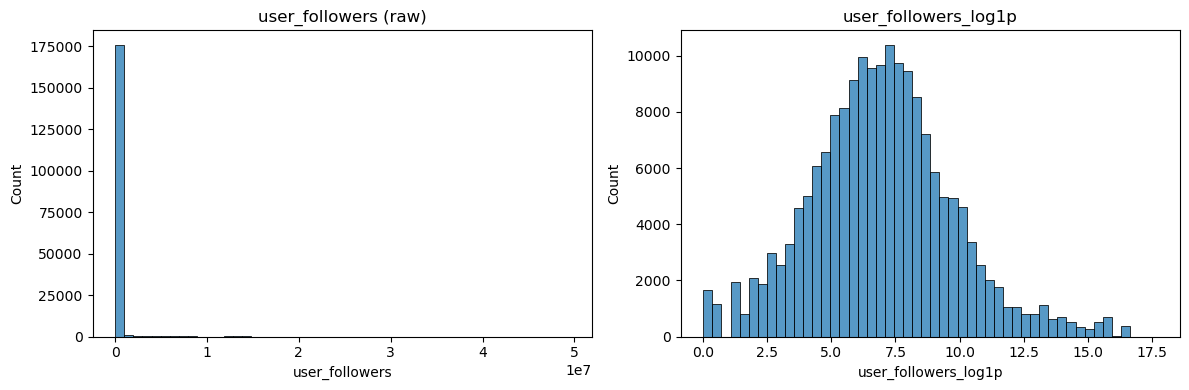

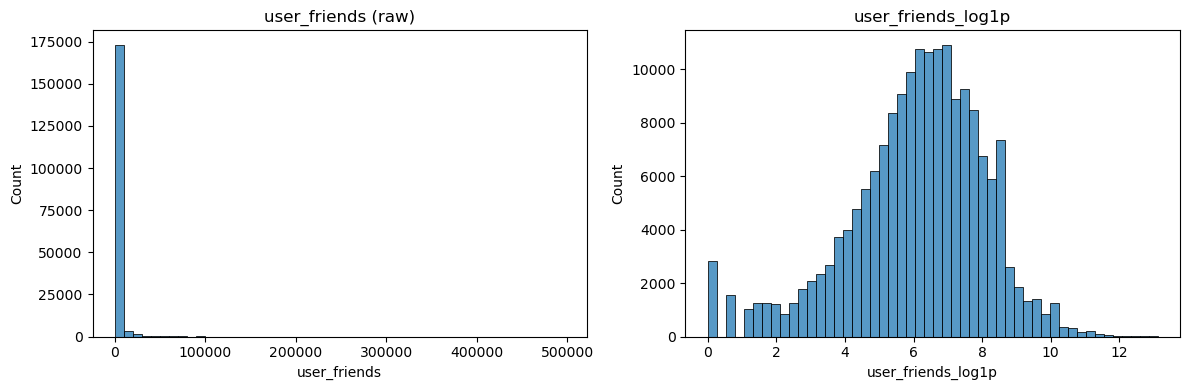

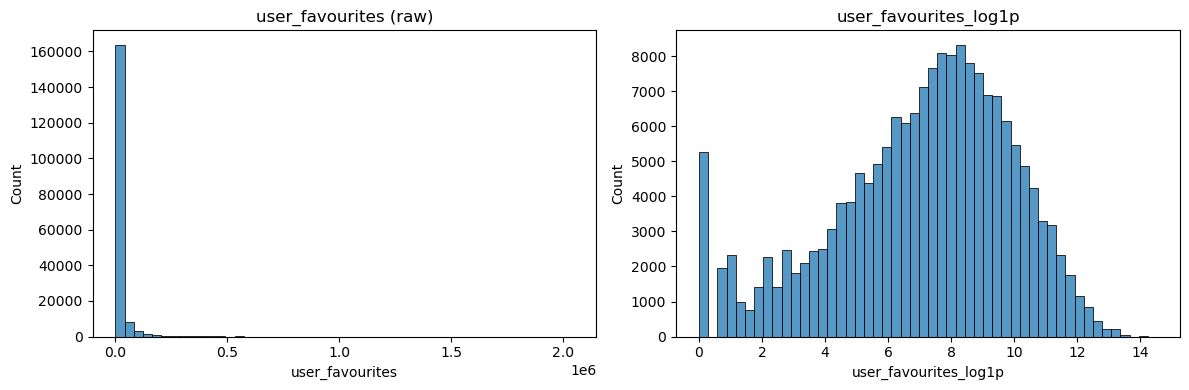

In [306]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_before_after_log(df, column):
    raw = df[column]
    logged = df[f'{column}_log1p']
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Before log-transform
    sns.histplot(raw, bins=50, ax=axes[0])
    axes[0].set_title(f'{column} (raw)')
    axes[0].set_xlabel(column)
    
    # After log-transform
    sns.histplot(logged, bins=50, ax=axes[1])
    axes[1].set_title(f'{column}_log1p')
    axes[1].set_xlabel(f'{column}_log1p')
    
    plt.tight_layout()
    plt.show()

for col in ['user_followers', 'user_friends', 'user_favourites']:
    plot_before_after_log(df, col)

### Observations from the Visualization(s):
For all three engagement metrics, the raw distributions are extremely right‑skewed: most users have relatively low follower/friend/favourite counts, while a small number have very large values, which dominate the scale of the feature. After applying a `log1p` transform, the distributions become much more compressed and closer to unimodal, with the bulk of the data spread over a narrow, interpretable range. This reduces the influence of genuine extremes while preserving their relative ordering, making these features safer to use in linear models that are sensitive to unscaled outliers.

In [307]:
df.isnull().sum()

user_location            36771
user_created                 0
user_followers               0
user_friends                 0
user_favourites              0
user_verified                0
date                         0
text                         0
hashtags                 51334
is_retweet                   0
user_id                      0
user_followers_log1p         0
user_friends_log1p           0
user_favourites_log1p        0
dtype: int64

In [308]:
def handle_missing_values_tweets(df, location_col='user_location', hashtags_col='hashtags'):
    """
    Handle missing values for key categorical/text fields in the COVID19 tweets dataset.

    - Missing user_location -> 'Unknown'
    - Missing hashtags -> 'no hashtags'
    """
    df_clean = df.copy()

    # 1. Treat missing user_location as "Unknown"
    if location_col in df_clean.columns:
        df_clean[location_col] = (
            df_clean[location_col]
            .fillna("Unknown")
            .astype(str)
            .str.strip()
        )

    # 2. Treat missing hashtags as "no hashtags"
    if hashtags_col in df_clean.columns:
        df_clean[hashtags_col] = (
            df_clean[hashtags_col]
            .fillna("no hashtags")
            .astype(str)
            .str.strip()
        )

    return df_clean


df = handle_missing_values_tweets(df)

### Explanation:
Missing `user_location` values are recoded as "Unknown" to preserve all rows while making the absence of location explicit. Missing `hashtags` are recoded as "no hashtags" to distinguish tweets that simply do not include hashtags from tweets where hashtag information is unavailable. No numerical imputation is needed at this stage because numerical columns have no missing values.

In [309]:
df.shape

(179108, 14)

In [310]:
import re

def label_tone_heuristic(text: str) -> str:
    """
    Heuristic tone labeling for COVID-19 tweets.
    Returns one of: 'fear_mongering', 'calm_negative', 'neutral_factual'.
    """
    t = str(text)
    t_lower = t.lower()
    
    # 1. Strong fear / catastrophe cues
    fear_words = [
        'we\'re doomed', 'end of the world', 'everyone will die',
        'apocalypse', 'doom', 'doomed', 'catastrophe', 'catastrophic',
        'disaster', 'devastating', 'panic', 'terrifying', 'deadly virus',
        'trumpvirus', 'killing us all'
    ]
    many_exclamations = t.count('!') >= 3
    all_caps_ratio = sum(1 for c in t if c.isupper()) / (len(t) + 1e-6)
    
    if any(w in t_lower for w in fear_words) or many_exclamations or all_caps_ratio > 0.4:
        return 'fear_mongering'
    
    # 2. Neutral / factual cues: numbers, cases, deaths, official language
    factual_patterns = [
        r'\b\d+\s+new cases\b',
        r'\b\d+\s+cases\b',
        r'\bdeaths?\b',
        r'\brecover(ed|ies)?\b',
        r'\bhospital\b',
        r'\bministry of health\b',
        r'\bwho\b',      # World Health Organization
        r'\bcdc\b',
        r'\bprime minister\b',
        r'\bcm\b',       # chief minister (India etc.)
    ]
    
    has_factual_pattern = any(re.search(p, t_lower) for p in factual_patterns)
    
    if has_factual_pattern or ('has no active cases' in t_lower) or ('tests positive for #covid19' in t_lower):
        return 'neutral_factual'
    
    # 3. Everything else that is critical / worried / opinionated but not clearly catastrophic
    negative_words = [
        'angry', 'worried', 'scared', 'upset', 'sad', 'anxious',
        'failed us', 'crisis', 'lockdown', 'lost my job', 'unemployment',
        'corrupt', 'incompetent', 'blame', 'responsible for'
    ]
    if any(w in t_lower for w in negative_words):
        return 'calm_negative'
    
    # Default: treat as neutral/factual (e.g., generic statements, mild sentiment)
    return 'neutral_factual'

In [311]:
df['tone_label'] = df['text'].apply(label_tone_heuristic)
df['tone_label'].value_counts(normalize=True)

tone_label
neutral_factual    0.937613
calm_negative      0.042360
fear_mongering     0.020027
Name: proportion, dtype: float64

<Axes: xlabel='tone_label'>

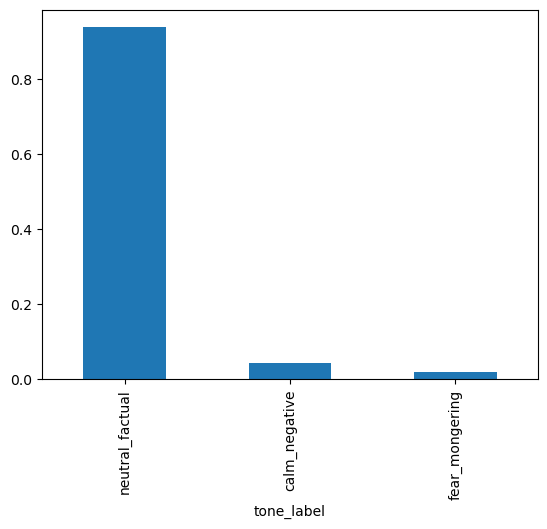

In [312]:
df['tone_label'].value_counts(normalize=True).plot.bar()

### Observations:
The target variable tone_label is heavily imbalanced. The vast majority of tweets are labeled neutral_factual (around 94%), while calm_negative and fear_mongering together account for only a small fraction of the data. This skew reflects the underlying stream of COVID‑19 tweets, where most posts are descriptive or mildly opinionated rather than overtly fear‑inducing. For modelling, this imbalance means that naive classifiers could achieve high overall accuracy by predicting the majority class, so later evaluation will emphasize class‑aware metrics (macro‑F1, per‑class precision/recall) and may require techniques such as class weights or resampling to ensure the minority tones are learned adequately.

In [313]:
for label in ['fear_mongering', 'calm_negative', 'neutral_factual']:
    print(f"\n=== {label} examples ===")
    print(df[df['tone_label'] == label]['text'].head(5).to_list())


=== fear_mongering examples ===
['I miss isopropyl alcohol so much!!!! Ethanol in hand sanitizer smells like I poured tequila on my hands 🤢 #COVID19', '“#Covid19 is everyone’s fight. I have covered major disasters, but nothing like this before." \n\n@fabeha_monir, a vi… https://t.co/q3f9kP8rsq', '1.28% of the U.S. population is infected with Covid-19 \n#COVID19 \n#TrumpVirus \n#MaskItOrCasket', '#coronavirus #COVID19 disproportionately affecting communities of color, especially #Hispanic #Latinx ones in my ho… https://t.co/01gV4rcK1u', '@BenJamesPhotos Italy #BenPC  #LOCKDOWNPHOTOCHALLENGE #COVID19 https://t.co/27jyDBhbMc']

=== calm_negative examples ===
['POPE AS GOD - Prophet Sadhu Sundar Selvaraj. Watch here at https://t.co/7X5RTyKVji \n\n#HurricaneHanna #COVID19… https://t.co/06dZcGUnwL', "@NicoleKowalski5 @chrisdameanor19 I'm feeling a little anxious because #COVID19 seems to have detracted everyone's… https://t.co/A3mHdXamLg", 'By the time you see a spike in #Covid19 cases, it 

### Tone Labeling Guidelines (v1)
These guidelines define the three tone classes used for the tone_label target. In this first version, labels are generated by a simple rule‑based function (label_tone_heuristic), so there will be some misclassifications; the rules and labels may be refined later after further inspection.

1. **fear_mongering**
    Tweets whose primary tone is to amplify fear or a sense of catastrophe around COVID‑19 or related issues.

    Uses highly emotional or catastrophic language.

    Emphasizes worst‑case outcomes without clear evidence (e.g., “we’re doomed”, “everyone will die”, “this will destroy X”, “Mask it or casket”).

    Often combines:

    - Strong negative framing about death, collapse, or existential threat, and/or

    - High emotional intensity (all‑caps, multiple exclamation marks) when used together with fear‑related words or hashtags.

    - May include conspiracy or blame narratives that amplify fear rather than inform (e.g., “this virus was designed to wipe us out”, “they’re hiding the real death toll”).

    **Note:** In this v1 heuristic, some tweets that are emotional or joking (e.g., “I miss isopropyl alcohol so much!!!!”) may be incorrectly flagged as `fear_mongering` because of the exclamation‑mark rule. This is a known limitation and will be revisited during error analysis.

2. **calm_negative** (concerned / critical / sad but not exaggerated)
    Tweets that are clearly negative in sentiment but do not frame the situation as an apocalypse.

    Express worry, frustration, anger, grief, or criticism in a grounded way.

    Talk about real negative impacts (job loss, family illness, mental health, policy criticism) without using end‑of‑the‑world or “everyone will die” framing.

    Can be strongly opinionated or political (“I’m angry at how the government handled COVID‑19”) but the tone is more “upset / critical” than “we are all doomed”.

3. **neutral_factual**
    Tweets whose main purpose is to inform or describe, possibly with mild sentiment, but not to induce fear.

    Mainly descriptive or informative: case numbers, hospitalizations, recoveries, policy changes, vaccine announcements, dates/locations, official statements.

    Uses relatively neutral language, possibly with mild positive/negative sentiment (“good news”, “concerning rise”), but without strong fear‑inducing framing.

    Often mentions sources (WHO, CDC, ministries, news outlets), locations, dates, or statistics, and uses a matter‑of‑fact tone.

**Default rule in v1:** When the heuristic does not detect strong fear cues or clear negative‑emotion cues, **tweets are assigned to neutral_factual by default**. This means the neutral_factual class currently dominates (≈94%) and likely contains a mix of truly neutral tweets and some that are more emotional but not caught by simple rules. This imbalance and noisiness will be taken into account when training and evaluating models.

In [314]:
output_path = "../data/interim/covid19_tweets_with_tone.csv"
df.to_csv(output_path, index=False)
print(f"Saved labeled data to {output_path}")

Saved labeled data to ../data/interim/covid19_tweets_with_tone.csv


In [315]:
df_v1 = pd.read_csv("../data/interim/covid19_tweets_with_tone.csv")
var_types_v1 = detect_variable_types(df_v1, target_col="tone_label")
var_types_v1

{'user_location': 'categorical',
 'user_created': 'categorical',
 'user_followers': 'numerical',
 'user_friends': 'numerical',
 'user_favourites': 'numerical',
 'user_verified': 'binary',
 'date': 'categorical',
 'text': 'text',
 'hashtags': 'categorical',
 'is_retweet': 'numerical',
 'user_id': 'numerical',
 'user_followers_log1p': 'numerical',
 'user_friends_log1p': 'numerical',
 'user_favourites_log1p': 'numerical',
 'tone_label': 'target'}

In [365]:
import logging
import os

LOG_PATH = "logs/preprocess.log"
os.makedirs("logs", exist_ok=True)

logging.basicConfig(
    level=logging.INFO,
    filename=LOG_PATH,
    filemode='w',
    format='%(asctime)s - %(levelname)s - %(message)s',
    force=True,
)

# Console handler – shows log lines in the cell output
console_handler = logging.StreamHandler()
console_handler.setLevel(logging.INFO)
console_handler.setFormatter(logging.Formatter('%(asctime)s - %(levelname)s - %(message)s'))
logging.getLogger().addHandler(console_handler)

logging.info("Starting preprocessing run.")

2026-05-27 00:03:13,727 - INFO - Starting preprocessing run.


In [366]:
from sklearn.model_selection import train_test_split
import logging

df_v2 = pd.read_csv("../data/interim/covid19_tweets_with_tone_copy.csv")
logging.info(f"Loaded data with shape {df_v2.shape}.")

X = df_v2.drop(columns=['tone_label', 'user_followers', 'user_friends', 'user_favourites'])
y = df_v2['tone_label']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

text_col = 'text'
numerical_cols = ['user_followers_log1p', 'user_friends_log1p', 'user_favourites_log1p', 'is_retweet', 'user_id', 'user_verified']
categorical_cols = ['user_location', 'user_created', 'date', 'hashtags']

logging.info(f"Numerical cols: {numerical_cols}")
logging.info(f"Categorical cols: {categorical_cols}")
logging.info(f"Text column: {text_col}")

2026-05-27 00:03:29,282 - INFO - Loaded data with shape (179108, 15).
2026-05-27 00:03:29,454 - INFO - Numerical cols: ['user_followers_log1p', 'user_friends_log1p', 'user_favourites_log1p', 'is_retweet', 'user_id', 'user_verified']
2026-05-27 00:03:29,455 - INFO - Categorical cols: ['user_location', 'user_created', 'date', 'hashtags']
2026-05-27 00:03:29,455 - INFO - Text column: text


### Pre-Processing Pipeline

In [317]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer

def create_preprocessing_pipeline(numerical_cols, categorical_cols, text_col):
    # Numerical pipeline
    numerical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    # Categorical pipeline
    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ])

    # Text pipeline (no imputer; TF‑IDF can handle empty strings)
    text_pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=20000,   # or something reasonable
            ngram_range=(1, 2),   # unigrams + bigrams
            min_df=5
        ))
    ])

    preprocessor = ColumnTransformer([
        ('num', numerical_pipeline, numerical_cols),
        ('cat', categorical_pipeline, categorical_cols),
        ('txt', text_pipeline, text_col)
    ], remainder='drop')

    return preprocessor

preprocessor = create_preprocessing_pipeline(
    numerical_cols=numerical_cols,
    categorical_cols=categorical_cols,
    text_col=text_col
)

In [347]:
from sklearn.linear_model import LogisticRegression

# by default, class is multinomial
clf = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        n_jobs=-1
    ))
])

clf.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['user_followers_log1p',
                                                   'user_friends_log1p',
                                                   'user_favourites_log1p',
                                                   'is_retweet', 'user_id',
                                                   'user_verified']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['user_location',
                                                   'user_created', 'date',
                                                   'hashtags']),
                                                 ('txt',
                                                  Pipeline(steps=[('tfidf',
                                                                   TfidfVectorizer(max_features=20000,
                                                                                   min_df=5,
                                                                                   ngram_range=(1,
                                                                                                2)))]),
                                                  'text')])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    n_jobs=-1))])

### Next Steps:
**To explore oversampling**, SMOTETomek was applied on a 10,000‑tweet subset of the training data rather than on the full TF‑IDF feature space. The full training set contains over 100k tweets and tens of thousands of sparse text features, which makes neighbour‑based methods like SMOTETomek computationally expensive and slow to run end‑to‑end. On the 10k subset, the original class distribution was still highly imbalanced (`neutral_factual`: `9,384`; `calm_negative`: `414`; `fear_mongering`: `202`), mirroring the proportions in the full dataset.

In [348]:
from imblearn.combine import SMOTETomek
from collections import Counter

X_small = X_train.sample(10000, random_state=42)
y_small = y_train.loc[X_small.index]

X_small_trans = clf.named_steps['preprocess'].fit_transform(X_small, y_small)
smote_tomek = SMOTETomek(random_state=42)
X_res_small, y_res_small = smote_tomek.fit_resample(X_small_trans, y_small)

print("Original:", Counter(y_small))
print("Resampled:", Counter(y_res_small))

Original: Counter({'neutral_factual': 9384, 'calm_negative': 414, 'fear_mongering': 202})
Resampled: Counter({'neutral_factual': 9384, 'calm_negative': 9384, 'fear_mongering': 9384})


In [349]:
from sklearn.linear_model import LogisticRegression

# by default, class is multinomial
logreg_resampled = LogisticRegression(
    max_iter=1000,
    class_weight=None,  # balance is handled by SMOTE
    n_jobs=-1
)

logreg_resampled.fit(X_res_small, y_res_small)

LogisticRegression(max_iter=1000, n_jobs=-1)

In [364]:
from sklearn.metrics import classification_report

# Using the same preprocessor that was fit on X_small, y_small
X_val_trans = clf.named_steps['preprocess'].transform(X_val)
y_val_pred_res = logreg_resampled.predict(X_val_trans)

report = classification_report(y_val, y_val_pred_res, output_dict=True)

display(pd.DataFrame(report).T.round(2))

,precision,recall,f1-score,support
calm_negative,0.92,0.46,0.61,1138.00
fear_mongering,0.81,0.11,0.20,538.00
neutral_factual,0.96,1.00,0.98,25190.00
accuracy,0.96,0.96,0.96,0.96
macro avg,0.90,0.52,0.60,26866.00
weighted avg,0.95,0.96,0.95,26866.00


### Observations:
**After resampling**, SMOTETomek produced a fully balanced training subset with 9,384 examples per class, and a simple Logistic Regression model trained on this oversampled data **showed higher recall for the minority classes** (especially `calm_negative`) compared with the baseline class‑weighted model, at the cost of a small drop in performance on the majority class. This confirms that oversampling can help the model pay more attention to rare tones, but due to computational limits it is used as a targeted experiment on a subset, while the main models on the full dataset rely on class weighting.

### Feature Engineering

In [367]:
df_v2['date'] = pd.to_datetime(df_v2['date'])
df_v2['user_created'] = pd.to_datetime(df_v2['user_created'])

# When was the tweet posted?
df_v2['tweet_year'] = df_v2['date'].dt.year
df_v2['tweet_month'] = df_v2['date'].dt.month        # 1–12
df_v2['tweet_dayofweek'] = df_v2['date'].dt.dayofweek  # 0=Mon

# Cyclical encoding for hour-of-day
df_v2['tweet_hour'] = df_v2['date'].dt.hour
df_v2['tweet_hour_sin'] = np.sin(2 * np.pi * df_v2['tweet_hour'] / 24)
df_v2['tweet_hour_cos'] = np.cos(2 * np.pi * df_v2['tweet_hour'] / 24)

# Account age in days at the time of tweet
df_v2['account_age_days'] = (df_v2['date'] - df_v2['user_created']).dt.days.clip(lower=0)

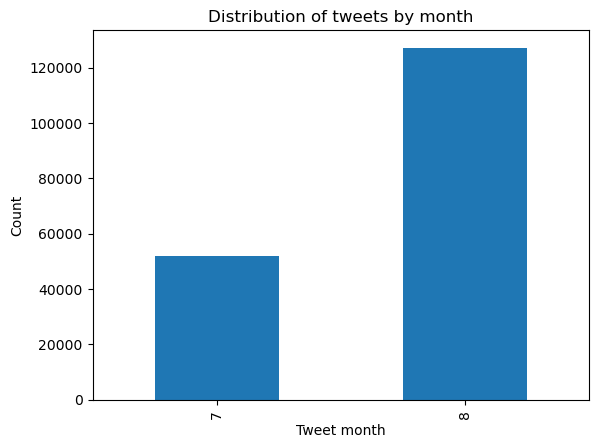

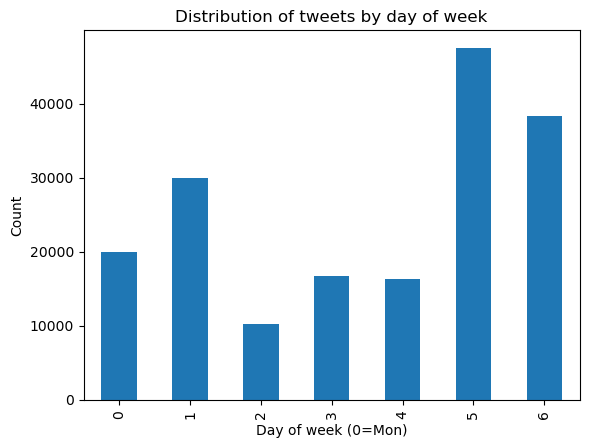

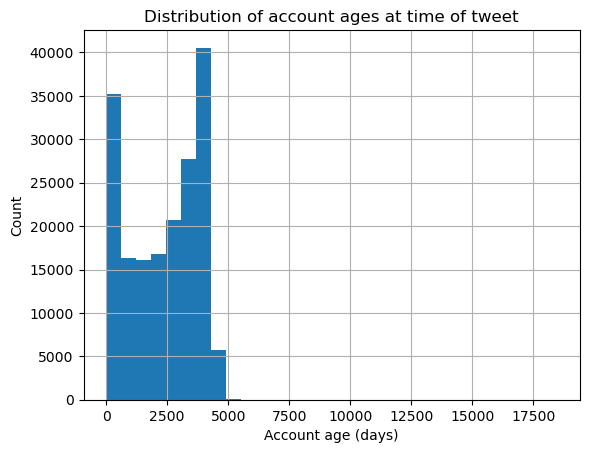

In [370]:
# Month of tweet
df_v2['tweet_month'].value_counts().sort_index().plot.bar()
plt.xlabel("Tweet month")
plt.ylabel("Count")
plt.title("Distribution of tweets by month")
plt.show()

# Day of week
df_v2['tweet_dayofweek'].value_counts().sort_index().plot.bar()
plt.xlabel("Day of week (0=Mon)")
plt.ylabel("Count")
plt.title("Distribution of tweets by day of week")
plt.show()

# Account age
df_v2['account_age_days'].hist(bins=30)
plt.xlabel("Account age (days)")
plt.ylabel("Count")
plt.title("Distribution of account ages at time of tweet")
plt.show()

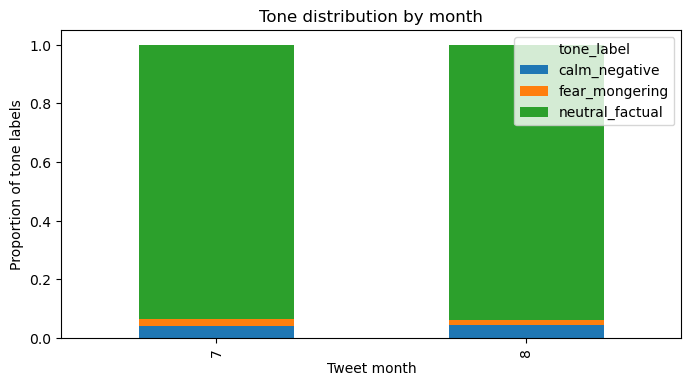

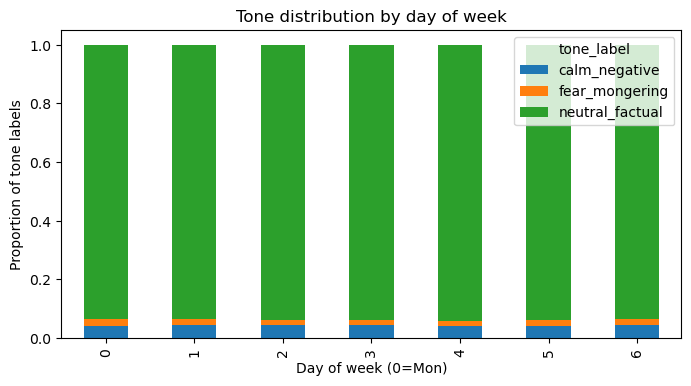

In [371]:
# Tone proportions by month
tone_by_month = (
    df_v2
    .groupby('tweet_month')['tone_label']
    .value_counts(normalize=True)
    .unstack()
)

tone_by_month.plot(kind='bar', stacked=True, figsize=(8,4))
plt.xlabel("Tweet month")
plt.ylabel("Proportion of tone labels")
plt.title("Tone distribution by month")
plt.legend(title="tone_label")
plt.show()

# Tone proportions by day of week
tone_by_dow = (
    df_v2
    .groupby('tweet_dayofweek')['tone_label']
    .value_counts(normalize=True)
    .unstack()
)

tone_by_dow.plot(kind='bar', stacked=True, figsize=(8,4))
plt.xlabel("Day of week (0=Mon)")
plt.ylabel("Proportion of tone labels")
plt.title("Tone distribution by day of week")
plt.legend(title="tone_label")
plt.show()

### Time-Related Feature Engineering and EDA Observations
From the tweet timestamp and account creation date, several time features were engineered: `tweet month`, `day of week`, and `account age` in days at the time of posting. The volume plots show that most tweets occur in August, with roughly 2.5 times more tweets than in July, and activity is higher toward the end of the week (especially on Saturdays and Sundays) compared with mid‑week. The account age histogram indicates that most tweets come from accounts that are at least several years old, with a long tail of very old accounts, suggesting that tone is largely driven by established users rather than newly created accounts. When looking at tone distributions by month and by day of week, the overall pattern remains similar: `neutral_factual` dominates on all days and in both months, with only small proportions of `calm_negative` and `fear_mongering` that do not show a strong systematic shift over time. These observations support including time‑derived features (month, day of week, account age, and cyclic hour‑of‑day) in the model to capture subtle temporal effects, even though coarse aggregates suggest that the global class imbalance is relatively stable over the observed period.

In [372]:
X = df_v2.drop(columns=['tone_label', 'date', 'user_created'])
y = df_v2['tone_label']

In [384]:
text_col = 'text'

numerical_cols = [
    'user_followers_log1p', 'user_friends_log1p', 'user_favourites_log1p',
    'is_retweet', 'user_id', 'user_verified',
    'tweet_year', 'tweet_month', 'tweet_dayofweek',
    'tweet_hour_sin', 'tweet_hour_cos',
    'account_age_days'
]

categorical_cols = ['user_location', 'hashtags']  # date-like cols moved to numeric

logging.info(f"Numerical cols v1: {numerical_cols}")
logging.info(f"Categorical cols v1: {categorical_cols}")

2026-05-27 20:57:58,401 - INFO - Numerical cols v1: ['user_followers_log1p', 'user_friends_log1p', 'user_favourites_log1p', 'is_retweet', 'user_id', 'user_verified', 'tweet_year', 'tweet_month', 'tweet_dayofweek', 'tweet_hour_sin', 'tweet_hour_cos', 'account_age_days']
2026-05-27 20:57:58,403 - INFO - Categorical cols v1: ['user_location', 'hashtags']


In [386]:
# Keep only top K locations and hashtags, others -> 'OTHER'
K = 50

top_locations = df_v2['user_location'].value_counts().nlargest(K).index
df_v2['user_location_top'] = df_v2['user_location'].where(df_v2['user_location'].isin(top_locations), 'OTHER')

top_hashtags = df_v2['hashtags'].value_counts().nlargest(K).index
df_v2['hashtags_top'] = df_v2['hashtags'].where(df_v2['hashtags'].isin(top_hashtags), 'OTHER')

categorical_cols = ['user_location_top', 'hashtags_top']

print(df_v2['user_location_top'].value_counts().head(10))
print(df_v2['hashtags_top'].value_counts().head(10))

user_location_top
OTHER               104076
Unknown              36777
India                 3803
United States         2470
New Delhi, India      1729
Mumbai, India         1403
Washington, DC        1373
London, England       1272
United Kingdom        1226
London                1135
Name: count, dtype: int64
hashtags_top
OTHER                                                                     74787
no hashtags                                                               51334
['COVID19']                                                               37792
['Covid19']                                                                4834
['covid19']                                                                3124
['coronavirus', 'CoronaVirusUpdate', 'COVID19', 'CoronavirusPandemic']      624
['coronavirus']                                                             550
['COVID19', 'coronavirus']                                                  519
['Coronavirus', 'COVID19']       

In [385]:
categorical_cols = ['user_location_top']  # hashtags dropped

logging.info(f"Categorical cols v2: {categorical_cols}")

2026-05-27 20:58:15,831 - INFO - Categorical cols v2: ['user_location_top']


### Treatment Explanation:
After grouping both `user_location` and `hashtags` into top‑K plus an OTHER bucket, I inspected their distributions. `user_location_top` retains a small, interpretable set of frequent locations (e.g., `Unknown`, `India`, `United States`, etc) and an OTHER category, which is suitable for one‑hot encoding. In contrast, `hashtags_top` is largely redundant with the tweet text, dominated by COVID‑related tags that already appear in the text column (e.g., `COVID19`, `coronavirus`, etc). To avoid redundant features and keep the model simpler, **I include only `user_location_top` as a categorical input and drop `hashtags_top`**, relying on TF‑IDF representations of the tweet text to capture hashtag content.